In [115]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [117]:
df = pd.read_csv("summary_crawled_12_04.csv")
df.head(2)

,elem_id,title,company_name,company_type,company_star,company_industry,company_size,country,location,date_posted,job_expertise,job_domain,skill_tags,job_description,job_requirements,job_benefits,working_model,working_days,overtime_policy,date_crawled,url
0,01-lead-net-developer-c-net-angular-tinh-van-consulting-0046,"01 Lead .NET Developer (C#, .NET, Angular)",Tinh Van Consulting,IT Product,3.6,Software Products and Web Services,51-150\nemployees,Vietnam,Ha Noi,Posted\n9 days ago,Fullstack Developer,['Software Products and Web Services'],"['.NET', 'ASP.NET', 'DevOps', 'JavaScript']","MÔ TẢ VỊ TRÍ\nChúng tôi tìm kiếm một .NET Dev Leader có năng lực để dẫn dắt nhóm phát triển và triển khai toàn\nbộ hệ thống Quản lý Nhân sự (HRM) từ giai đoạn thiết kế kiến trúc đến go-live.\nTRÁCH NHIỆM CHÍNH\n1. Lãnh đạo kỹ thuật & Quản lý nhóm\n• Dẫn dắt nhóm 3–8 lập trình viên .NET trong toàn bộ vòng đời phát triển HRM\n• Phân công công việc, review code, mentor và hỗ trợ kỹ thuật cho các thành viên\n• Lập kế hoạch dự án theo mô hình Waterfall kết hợp Agile: định nghĩa rõ các phase (phân tích,\nthiết kế, phát triển, kiểm thử, go-live) đồng thời áp dụng sprint ngắn trong từng phase\n• Tổ chức daily stand-up, sprint planning, retrospective trong từng giai đoạn phát triển\n• Đánh giá năng lực và đề xuất lộ trình phát triển cho từng thành viên\n2. Thiết kế kiến trúc & Kỹ thuật\n• Thiết kế và xây dựng kiến trúc hệ thống HRM với backend .NET 9 trở lên và frontend Angular\n• Xây dựng API RESTful / GraphQL phục vụ các module: tuyển dụng, chấm công, lương, đánh\ngiá KPI\n• Thiết kế database (SQL Server / PostgreSQL/Oracle) đảm bảo hiệu năng và tính toàn vẹn dữ liệu\n• Tích hợp các hệ thống bên thứ ba: LDAP/AD, hệ thống lương, ERP, phần mềm chấm công\n• Đảm bảo bảo mật hệ thống: xác thực OAuth2/JWT, phân quyền RBAC, mã hóa dữ liệu nhạy\ncảm\n3. Triển khai & Vận hành\n• Lập kế hoạch triển khai chi tiết theo từng phase (Waterfall): phân tích yêu cầu → thiết kế →\nphát triển → kiểm thử → nghiệm thu → go-live; quản lý rủi ro và đảm bảo tiến độ\n• Thiết lập CI/CD pipeline (Azure DevOps / GitHub Actions / Jenkins)\n• Triển khai và cấu hình môi trường: On-premise/Azure/AWS\n• Xây dựng quy trình kiểm thử, đảm bảo chất lượng (unit test, integration test, UAT)\n• Phối hợp với bộ phận HR và Business Analyst để thu thập và chuẩn hóa yêu cầu nghiệp vụ\n4. Tài liệu & Chuyển giao\n• Viết tài liệu kỹ thuật: kiến trúc, API spec, hướng dẫn vận hành• Thực hiện đào tạo và chuyển giao hệ thống cho đội vận hành (IT Ops)\n• Hỗ trợ hypercare sau go-live, xử lý sự cố và tối ưu hiệu năng","YÊU CẦU\n1. Kỹ năng kỹ thuật bắt buộc\n•\nThành thạo C# / .NET 9 (ASP.NET Core, Entity Framework Core, LINQ, Minimal API)\n•\nThành thạo Angular (v16+): component architecture, RxJS, NgRx, Angular Material\n• Kinh nghiệm thiết kế Microservices, RESTful API, gRPC\n•\nSQL Server: query optimization, stored procedure, indexing, execution plan\n• Kiến thức Oracle Database là lợi thế lớn (PL/SQL, Oracle-specific optimization)\n• Kinh nghiệm với Azure / AWS hoặc môi trường cloud tương đương\n• Hiểu biết vững về Design Patterns, SOLID, Clean Architecture / DDD\n• CI/CD: Azure DevOps, GitHub Actions, Jenkins, Docker, Kubernetes\n• Bảo mật: OAuth2, OpenID Connect, JWT, mã hóa dữ liệu\n2. Kỹ năng ưu tiên\n• Đã từng triển khai hoặc tham gia dự án HRM / ERP / HRMS\n• Kinh nghiệm tích hợp LDAP / Active Directory\n• Biết sử dụng message queue: RabbitMQ, Azure Service Bus, Kafka\n• Kinh nghiệm tối ưu hiệu năng Angular: lazy loading, change detection, bundle optimization\n• Có kiến thức về quy trình HR: tuyển dụng, payroll, chấm công, KPI\n3. Kỹ năng mềm & Quản lý\n• Am hiểu và có kinh nghiệm triển khai dự án theo mô hình Waterfall kết hợp Agile\n• Khả năng giao tiếp, trình bày rõ ràng với stakeholder không chuyên kỹ thuật\n• Tư duy hệ thống, chủ động đề xuất giải pháp, chịu được áp lực tiến độ\n• Kỹ năng đọc hiểu tài liệu tiếng Anh kỹ thuật","+ Được hưởng mức lương hấp dẫn tương xứng theo khả năng và hiệu qu

In [118]:
#Chuyển địa chỉ thành 3 nhóm chính: Hà Nội, TPHCM hoặc cả 2
def standardize_city(location):
    is_hcm = 'Ho Chi Minh' in location
    is_hn = 'Ha Noi' in location

    if is_hcm and is_hn:
        return "Hà Nội & TPHCM"
    elif is_hcm:
        return "TPHCM"
    elif is_hn:
        return "Hà Nội"

df['city_group'] = df['location'].apply(standardize_city)

In [119]:
# Remove '\nemployees' from the 'company_size' column
df['company_size'] = df['company_size'].str.replace('\nemployees', '', regex=False)

In [120]:
#Tính date_posted chính xác
df['date_crawled'] = pd.to_datetime(df['date_crawled'])

def calculate_real_date(row):
    text = str(row['date_posted']).lower()
    crawled_date = row['date_crawled']

    number_match = re.search(r'\d+', text)
    if not number_match:
        return crawled_date

    num = int(number_match.group())
    if 'minute' in text:
        return crawled_date - pd.Timedelta(minutes=num)
    elif 'hour' in text:
        return crawled_date - pd.Timedelta(hours=num)
    elif 'day' in text:
        return crawled_date - pd.Timedelta(days=num)
    elif 'month' in text:
        return crawled_date - pd.Timedelta(days=num * 30)

    return crawled_date

df['date_posted_clean'] = df.apply(calculate_real_date, axis=1)
df['date_posted_clean'] = pd.to_datetime(df['date_posted_clean']).dt.normalize()

In [121]:
df.head(20)

,elem_id,title,company_name,company_type,company_star,company_industry,company_size,country,location,date_posted,job_expertise,job_domain,skill_tags,job_description,job_requirements,job_benefits,working_model,working_days,overtime_policy,date_crawled,url,city_group,date_posted_clean
0,01-lead-net-developer-c-net-angular-tinh-van-consulting-0046,"01 Lead .NET Developer (C#, .NET, Angular)",Tinh Van Consulting,IT Product,3.6,Software Products and Web Services,51-150,Vietnam,Ha Noi,Posted\n9 days ago,Fullstack Developer,['Software Products and Web Services'],"['.NET', 'ASP.NET', 'DevOps', 'JavaScript']","MÔ TẢ VỊ TRÍ\nChúng tôi tìm kiếm một .NET Dev Leader có năng lực để dẫn dắt nhóm phát triển và triển khai toàn\nbộ hệ thống Quản lý Nhân sự (HRM) từ giai đoạn thiết kế kiến trúc đến go-live.\nTRÁCH NHIỆM CHÍNH\n1. Lãnh đạo kỹ thuật & Quản lý nhóm\n• Dẫn dắt nhóm 3–8 lập trình viên .NET trong toàn bộ vòng đời phát triển HRM\n• Phân công công việc, review code, mentor và hỗ trợ kỹ thuật cho các thành viên\n• Lập kế hoạch dự án theo mô hình Waterfall kết hợp Agile: định nghĩa rõ các phase (phân tích,\nthiết kế, phát triển, kiểm thử, go-live) đồng thời áp dụng sprint ngắn trong từng phase\n• Tổ chức daily stand-up, sprint planning, retrospective trong từng giai đoạn phát triển\n• Đánh giá năng lực và đề xuất lộ trình phát triển cho từng thành viên\n2. Thiết kế kiến trúc & Kỹ thuật\n• Thiết kế và xây dựng kiến trúc hệ thống HRM với backend .NET 9 trở lên và frontend Angular\n• Xây dựng API RESTful / GraphQL phục vụ các module: tuyển dụng, chấm công, lương, đánh\ngiá KPI\n• Thiết kế database (SQL Server / PostgreSQL/Oracle) đảm bảo hiệu năng và tính toàn vẹn dữ liệu\n• Tích hợp các hệ thống bên thứ ba: LDAP/AD, hệ thống lương, ERP, phần mềm chấm công\n• Đảm bảo bảo mật hệ thống: xác thực OAuth2/JWT, phân quyền RBAC, mã hóa dữ liệu nhạy\ncảm\n3. Triển khai & Vận hành\n• Lập kế hoạch triển khai chi tiết theo từng phase (Waterfall): phân tích yêu cầu → thiết kế →\nphát triển → kiểm thử → nghiệm thu → go-live; quản lý rủi ro và đảm bảo tiến độ\n• Thiết lập CI/CD pipeline (Azure DevOps / GitHub Actions / Jenkins)\n• Triển khai và cấu hình môi trường: On-premise/Azure/AWS\n• Xây dựng quy trình kiểm thử, đảm bảo chất lượng (unit test, integration test, UAT)\n• Phối hợp với bộ phận HR và Business Analyst để thu thập và chuẩn hóa yêu cầu nghiệp vụ\n4. Tài liệu & Chuyển giao\n• Viết tài liệu kỹ thuật: kiến trúc, API spec, hướng dẫn vận hành• Thực hiện đào tạo và chuyển giao hệ thống cho đội vận hành (IT Ops)\n• Hỗ trợ hypercare sau go-live, xử lý sự cố và tối ưu hiệu năng","YÊU CẦU\n1. Kỹ năng kỹ thuật bắt buộc\n•\nThành thạo C# / .NET 9 (ASP.NET Core, Entity Framework Core, LINQ, Minimal API)\n•\nThành thạo Angular (v16+): component architecture, RxJS, NgRx, Angular Material\n• Kinh nghiệm thiết kế Microservices, RESTful API, gRPC\n•\nSQL Server: query optimization, stored procedure, indexing, execution plan\n• Kiến thức Oracle Database là lợi thế lớn (PL/SQL, Oracle-specific optimization)\n• Kinh nghiệm với Azure / AWS hoặc môi trường cloud tương đương\n• Hiểu biết vững về Design Patterns, SOLID, Clean Architecture / DDD\n• CI/CD: Azure DevOps, GitHub Actions, Jenkins, Docker, Kubernetes\n• Bảo mật: OAuth2, OpenID Connect, JWT, mã hóa dữ liệu\n2. Kỹ năng ưu tiên\n• Đã từng triển khai hoặc tham gia dự án HRM / ERP / HRMS\n• Kinh nghiệm tích hợp LDAP / Active Directory\n• Biết sử dụng message queue: RabbitMQ, Azure Service Bus, Kafka\n• Kinh nghiệm tối ưu hiệu năng Angular: lazy loading, change detection, bundle optimization\n• Có kiến thức về quy trình HR: tuyển dụng, payroll, chấm công, KPI\n3. Kỹ năng mềm & Quản lý\n• Am hiểu và có kinh nghiệm triển khai dự án theo mô hình Waterfall kết hợp Agile\n• Khả năng giao tiếp, trình bày rõ ràng với stakeholder không chuyên kỹ thuật\n• Tư duy hệ thống, chủ động đề xuất giải pháp, chịu được áp lực tiến độ\n• Kỹ năng đọc hiểu tài liệu tiếng Anh kỹ thuật","+ Được hưởng mức lương hấp dẫn tương xứng theo k

In [122]:
# Tính during_date
def process_elem_id(group):
    min_date = group['date_posted_clean'].min()
    max_date = group['date_crawled'].max()
    during_days = (max_date - min_date).days

    representative_row = group.sort_values(by='date_crawled', ascending=False).iloc[0].copy()
    representative_row['during_days'] = during_days
    return representative_row

df = df.groupby('elem_id', group_keys=False).apply(process_elem_id).reset_index(drop=True)
df.head(2)

/tmp/ipykernel_5013/1222306427.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('elem_id', group_keys=False).apply(process_elem_id).reset_index(drop=True)


,elem_id,title,company_name,company_type,company_star,company_industry,company_size,country,location,date_posted,job_expertise,job_domain,skill_tags,job_description,job_requirements,job_benefits,working_model,working_days,overtime_policy,date_crawled,url,city_group,date_posted_clean,during_days
0,01-lead-net-developer-c-net-angular-tinh-van-consulting-0046,"01 Lead .NET Developer (C#, .NET, Angular)",Tinh Van Consulting,IT Product,3.6,Software Products and Web Services,51-150,Vietnam,Ha Noi,Posted\n18 days ago,Fullstack Developer,['Software Products and Web Services'],"['.NET', 'ASP.NET', 'DevOps', 'JavaScript']","MÔ TẢ VỊ TRÍ\nChúng tôi tìm kiếm một .NET Dev Leader có năng lực để dẫn dắt nhóm phát triển và triển khai toàn\nbộ hệ thống Quản lý Nhân sự (HRM) từ giai đoạn thiết kế kiến trúc đến go-live.\nTRÁCH NHIỆM CHÍNH\n1. Lãnh đạo kỹ thuật & Quản lý nhóm\n• Dẫn dắt nhóm 3–8 lập trình viên .NET trong toàn bộ vòng đời phát triển HRM\n• Phân công công việc, review code, mentor và hỗ trợ kỹ thuật cho các thành viên\n• Lập kế hoạch dự án theo mô hình Waterfall kết hợp Agile: định nghĩa rõ các phase (phân tích,\nthiết kế, phát triển, kiểm thử, go-live) đồng thời áp dụng sprint ngắn trong từng phase\n• Tổ chức daily stand-up, sprint planning, retrospective trong từng giai đoạn phát triển\n• Đánh giá năng lực và đề xuất lộ trình phát triển cho từng thành viên\n2. Thiết kế kiến trúc & Kỹ thuật\n• Thiết kế và xây dựng kiến trúc hệ thống HRM với backend .NET 9 trở lên và frontend Angular\n• Xây dựng API RESTful / GraphQL phục vụ các module: tuyển dụng, chấm công, lương, đánh\ngiá KPI\n• Thiết kế database (SQL Server / PostgreSQL/Oracle) đảm bảo hiệu năng và tính toàn vẹn dữ liệu\n• Tích hợp các hệ thống bên thứ ba: LDAP/AD, hệ thống lương, ERP, phần mềm chấm công\n• Đảm bảo bảo mật hệ thống: xác thực OAuth2/JWT, phân quyền RBAC, mã hóa dữ liệu nhạy\ncảm\n3. Triển khai & Vận hành\n• Lập kế hoạch triển khai chi tiết theo từng phase (Waterfall): phân tích yêu cầu → thiết kế →\nphát triển → kiểm thử → nghiệm thu → go-live; quản lý rủi ro và đảm bảo tiến độ\n• Thiết lập CI/CD pipeline (Azure DevOps / GitHub Actions / Jenkins)\n• Triển khai và cấu hình môi trường: On-premise/Azure/AWS\n• Xây dựng quy trình kiểm thử, đảm bảo chất lượng (unit test, integration test, UAT)\n• Phối hợp với bộ phận HR và Business Analyst để thu thập và chuẩn hóa yêu cầu nghiệp vụ\n4. Tài liệu & Chuyển giao\n• Viết tài liệu kỹ thuật: kiến trúc, API spec, hướng dẫn vận hành• Thực hiện đào tạo và chuyển giao hệ thống cho đội vận hành (IT Ops)\n• Hỗ trợ hypercare sau go-live, xử lý sự cố và tối ưu hiệu năng","YÊU CẦU\n1. Kỹ năng kỹ thuật bắt buộc\n•\nThành thạo C# / .NET 9 (ASP.NET Core, Entity Framework Core, LINQ, Minimal API)\n•\nThành thạo Angular (v16+): component architecture, RxJS, NgRx, Angular Material\n• Kinh nghiệm thiết kế Microservices, RESTful API, gRPC\n•\nSQL Server: query optimization, stored procedure, indexing, execution plan\n• Kiến thức Oracle Database là lợi thế lớn (PL/SQL, Oracle-specific optimization)\n• Kinh nghiệm với Azure / AWS hoặc môi trường cloud tương đương\n• Hiểu biết vững về Design Patterns, SOLID, Clean Architecture / DDD\n• CI/CD: Azure DevOps, GitHub Actions, Jenkins, Docker, Kubernetes\n• Bảo mật: OAuth2, OpenID Connect, JWT, mã hóa dữ liệu\n2. Kỹ năng ưu tiên\n• Đã từng triển khai hoặc tham gia dự án HRM / ERP / HRMS\n• Kinh nghiệm tích hợp LDAP / Active Directory\n• Biết sử dụng message queue: RabbitMQ, Azure Service Bus, Kafka\n• Kinh nghiệm tối ưu hiệu năng Angular: lazy loading, change detection, bundle optimization\n• Có kiến thức về quy trình HR: tuyển dụng, payroll, chấm công, KPI\n3. Kỹ năng mềm & Quản lý\n• Am hiểu và có kinh nghiệm triển khai dự án theo mô hình Waterfall kết hợp Agile\n• Khả năng giao tiếp, trình bày rõ ràng với stakeholder không chuyên kỹ thuật\n• Tư duy hệ thống, chủ động đề xuất giải pháp, chịu được áp lực tiến độ\n• Kỹ năng đọc hiểu tài liệu tiếng Anh kỹ thuật","+ Được hưởng mức lương hấp dẫn tươn

In [123]:
# Thay working_days bằng biến work_on_saturday
df['work_on_saturday'] = False
for index, row in df.iterrows():
    if row['working_days'] == 'Monday - Saturday':
        df.at[index, 'work_on_saturday'] = True

In [124]:
#Nhận diện các tin đăng lại (cùng tiêu đề, cùng công ty, cùng địa điểm)
identity_columns = ['title', 'company_name','location']
duplicate_mask = df.duplicated(subset=identity_columns, keep='first')

In [125]:
#Thống kê sau khi clean
total_before = len(df)
df_clean = df[~duplicate_mask].copy().reset_index(drop=True)
total_after = len(df_clean)

print(f"1. Tổng số dòng ban đầu: {total_before}")
print(f"2. Số dòng trùng lặp (re-posted): {duplicate_mask.sum()}")
print(f"3. Số dòng còn lại sau khi dọn dẹp: {total_after}")

1. Tổng số dòng ban đầu: 1799
2. Số dòng trùng lặp (re-posted): 64
3. Số dòng còn lại sau khi dọn dẹp: 1735


In [126]:
# Tạo mới id
df_clean['elem_id'] = df_clean.index + 1

In [127]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1735 entries, 0 to 1734
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   elem_id            1735 non-null   int64         
 1   title              1735 non-null   object        
 2   company_name       1735 non-null   object        
 3   company_type       1735 non-null   object        
 4   company_star       1735 non-null   object        
 5   company_industry   1735 non-null   object        
 6   company_size       1735 non-null   object        
 7   country            1735 non-null   object        
 8   location           1735 non-null   object        
 9   date_posted        1735 non-null   object        
 10  job_expertise      1735 non-null   object        
 11  job_domain         1735 non-null   object        
 12  skill_tags         1735 non-null   object        
 13  job_description    1735 non-null   object        
 14  job_requ

In [128]:
df_clean.head(10)

,elem_id,title,company_name,company_type,company_star,company_industry,company_size,country,location,date_posted,job_expertise,job_domain,skill_tags,job_description,job_requirements,job_benefits,working_model,working_days,overtime_policy,date_crawled,url,city_group,date_posted_clean,during_days,work_on_saturday
0,1,"01 Lead .NET Developer (C#, .NET, Angular)",Tinh Van Consulting,IT Product,3.6,Software Products and Web Services,51-150,Vietnam,Ha Noi,Posted\n18 days ago,Fullstack Developer,['Software Products and Web Services'],"['.NET', 'ASP.NET', 'DevOps', 'JavaScript']","MÔ TẢ VỊ TRÍ\nChúng tôi tìm kiếm một .NET Dev Leader có năng lực để dẫn dắt nhóm phát triển và triển khai toàn\nbộ hệ thống Quản lý Nhân sự (HRM) từ giai đoạn thiết kế kiến trúc đến go-live.\nTRÁCH NHIỆM CHÍNH\n1. Lãnh đạo kỹ thuật & Quản lý nhóm\n• Dẫn dắt nhóm 3–8 lập trình viên .NET trong toàn bộ vòng đời phát triển HRM\n• Phân công công việc, review code, mentor và hỗ trợ kỹ thuật cho các thành viên\n• Lập kế hoạch dự án theo mô hình Waterfall kết hợp Agile: định nghĩa rõ các phase (phân tích,\nthiết kế, phát triển, kiểm thử, go-live) đồng thời áp dụng sprint ngắn trong từng phase\n• Tổ chức daily stand-up, sprint planning, retrospective trong từng giai đoạn phát triển\n• Đánh giá năng lực và đề xuất lộ trình phát triển cho từng thành viên\n2. Thiết kế kiến trúc & Kỹ thuật\n• Thiết kế và xây dựng kiến trúc hệ thống HRM với backend .NET 9 trở lên và frontend Angular\n• Xây dựng API RESTful / GraphQL phục vụ các module: tuyển dụng, chấm công, lương, đánh\ngiá KPI\n• Thiết kế database (SQL Server / PostgreSQL/Oracle) đảm bảo hiệu năng và tính toàn vẹn dữ liệu\n• Tích hợp các hệ thống bên thứ ba: LDAP/AD, hệ thống lương, ERP, phần mềm chấm công\n• Đảm bảo bảo mật hệ thống: xác thực OAuth2/JWT, phân quyền RBAC, mã hóa dữ liệu nhạy\ncảm\n3. Triển khai & Vận hành\n• Lập kế hoạch triển khai chi tiết theo từng phase (Waterfall): phân tích yêu cầu → thiết kế →\nphát triển → kiểm thử → nghiệm thu → go-live; quản lý rủi ro và đảm bảo tiến độ\n• Thiết lập CI/CD pipeline (Azure DevOps / GitHub Actions / Jenkins)\n• Triển khai và cấu hình môi trường: On-premise/Azure/AWS\n• Xây dựng quy trình kiểm thử, đảm bảo chất lượng (unit test, integration test, UAT)\n• Phối hợp với bộ phận HR và Business Analyst để thu thập và chuẩn hóa yêu cầu nghiệp vụ\n4. Tài liệu & Chuyển giao\n• Viết tài liệu kỹ thuật: kiến trúc, API spec, hướng dẫn vận hành• Thực hiện đào tạo và chuyển giao hệ thống cho đội vận hành (IT Ops)\n• Hỗ trợ hypercare sau go-live, xử lý sự cố và tối ưu hiệu năng","YÊU CẦU\n1. Kỹ năng kỹ thuật bắt buộc\n•\nThành thạo C# / .NET 9 (ASP.NET Core, Entity Framework Core, LINQ, Minimal API)\n•\nThành thạo Angular (v16+): component architecture, RxJS, NgRx, Angular Material\n• Kinh nghiệm thiết kế Microservices, RESTful API, gRPC\n•\nSQL Server: query optimization, stored procedure, indexing, execution plan\n• Kiến thức Oracle Database là lợi thế lớn (PL/SQL, Oracle-specific optimization)\n• Kinh nghiệm với Azure / AWS hoặc môi trường cloud tương đương\n• Hiểu biết vững về Design Patterns, SOLID, Clean Architecture / DDD\n• CI/CD: Azure DevOps, GitHub Actions, Jenkins, Docker, Kubernetes\n• Bảo mật: OAuth2, OpenID Connect, JWT, mã hóa dữ liệu\n2. Kỹ năng ưu tiên\n• Đã từng triển khai hoặc tham gia dự án HRM / ERP / HRMS\n• Kinh nghiệm tích hợp LDAP / Active Directory\n• Biết sử dụng message queue: RabbitMQ, Azure Service Bus, Kafka\n• Kinh nghiệm tối ưu hiệu năng Angular: lazy loading, change detection, bundle optimization\n• Có kiến thức về quy trình HR: tuyển dụng, payroll, chấm công, KPI\n3. Kỹ năng mềm & Quản lý\n• Am hiểu và có kinh nghiệm triển khai dự án theo mô hình Waterfall kết hợp Agile\n• Khả năng giao tiếp, trình bày rõ ràng với stakeholder không chuyên kỹ thuật\n• Tư duy hệ thống, chủ động đề xuất giải pháp, chịu được áp lực tiến độ\n• Kỹ năng đọc hiểu tài liệu tiếng Anh kỹ thuật","+ Được hưởng mức lương hấp dẫn tương xứng theo khả năng và hiệu quả công việc

In [129]:
import ast
def parse_string_to_list(x):
    if pd.isna(x) or x == "" or x == "[]":
        return []
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return [i.strip() for i in str(x).split(',')]
df_clean['job_domain'] = df_clean['job_domain'].apply(parse_string_to_list)
df_clean['skill_tags'] = df_clean['skill_tags'].apply(parse_string_to_list)

In [130]:
print(df_clean['job_domain'].unique)

<bound method Series.unique of 0                                                                                                                           [Software Products and Web Services]
1                                                                                                                           [Software Products and Web Services]
2                                                                                                                                                         [Game]
3                                                                                                                           [Software Products and Web Services]
4                                                                             [E-commerce, Software Development Outsourcing, Software Products and Web Services]
                                                                                  ...                                                                           
173

In [131]:
df_domains = df_clean[['elem_id', 'job_domain']].explode('job_domain')
df_domains = df_domains.rename(columns={'job_domain': 'domain_name'})

In [132]:
df_domains.head(20)

,elem_id,domain_name
0,1,Software Products and Web Services
1,2,Software Products and Web Services
2,3,Game
3,4,Software Products and Web Services
4,5,E-commerce
4,5,Software Development Outsourcing
4,5,Software Products and Web Services
5,6,E-commerce
5,6,Financial Services
6,7,IT Services and IT Consulting


In [133]:
df_domains.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3313 entries, 0 to 1734
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   elem_id      3313 non-null   int64 
 1   domain_name  3313 non-null   object
dtypes: int64(1), object(1)
memory usage: 77.6+ KB


In [134]:
df_domains['domain_name'].unique()
print("Số lượng các domain khác nhau là:", df_domains['domain_name'].nunique())

Số lượng các domain khác nhau là: 40


In [135]:
df_skills = df_clean[['elem_id', 'skill_tags']].explode('skill_tags')
df_skills = df_skills.rename(columns={'skill_tags': 'skill_name'})

In [136]:
df_skills.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8785 entries, 0 to 1734
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   elem_id     8785 non-null   int64 
 1   skill_name  8785 non-null   object
dtypes: int64(1), object(1)
memory usage: 205.9+ KB


In [137]:
print("Số lượng các skill_tags khác nhau là:", df_skills['skill_name'].nunique())

Số lượng các skill_tags khác nhau là: 401


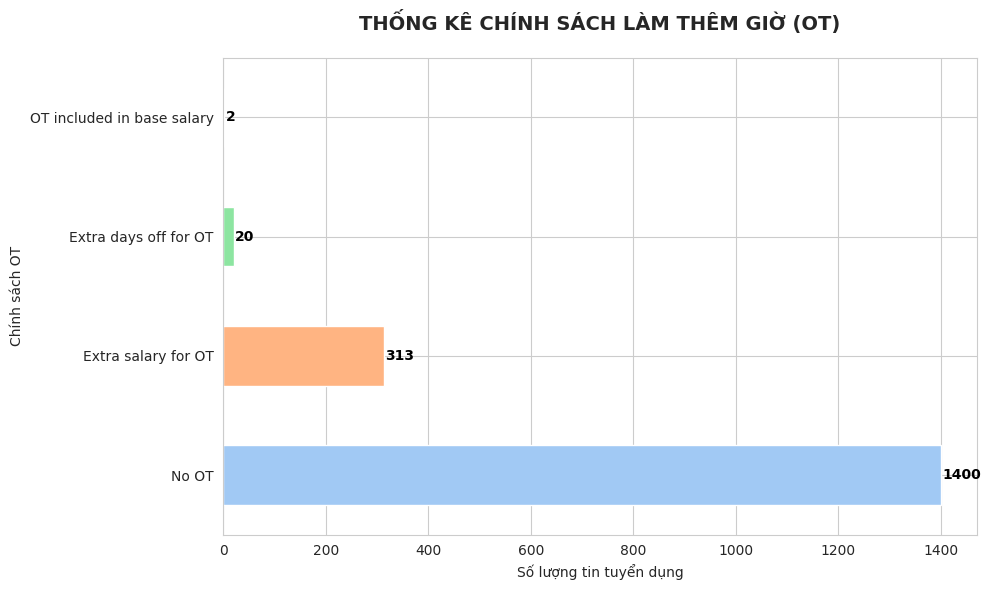

In [138]:
ot_counts = df_clean['overtime_policy'].value_counts()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

colors = sns.color_palette('pastel')[0:len(ot_counts)]
ax = ot_counts.plot(kind='barh', color=colors)
for i, v in enumerate(ot_counts):
    ax.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.title('THỐNG KÊ CHÍNH SÁCH LÀM THÊM GIỜ (OT)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Số lượng tin tuyển dụng')
plt.ylabel('Chính sách OT')
plt.tight_layout()
plt.show()

In [139]:
domain_counts = df_domains['domain_name'].value_counts()
print("Thống kê số lượng Job theo từng Domain:")
print(domain_counts)

Thống kê số lượng Job theo từng Domain:
domain_name
Software Products and Web Services         725
IT Services and IT Consulting              554
Financial Services                         315
Banking                                    280
Software Development Outsourcing           240
AI Software & Services                     239
E-commerce                                 160
Game                                        72
Transportation, Logistics and Warehouse     56
IT Hardware and Computing                   54
Securities & Investment                     52
Insurance                                   51
Healthcare                                  50
Education and Training                      43
Manufacturing and Engineering               42
Emerging Tech R&D                           38
Real Estate, Property and Construction      35
Cyber Security                              33
Telecommunication                           31
Blockchain & Web3 Services                  30
Retail a

In [140]:
expertise_counts = df_clean['job_expertise'].value_counts()
print("Thống kê số lượng Job theo từng expertise:")
print(expertise_counts)

Thống kê số lượng Job theo từng expertise:
job_expertise
Backend Developer                         266
Fullstack Developer                       174
Frontend Developer                         96
AI / Machine Learning Engineer             93
Mobile Application Developer               92
                                         ... 
Analytics Engineer                          1
Technical Consultant                        1
Integration & Legacy Systems Developer      1
Field Support                               1
UX Researcher                               1
Name: count, Length: 80, dtype: int64


In [141]:
df_domains.to_csv('df_domains.csv', index=False, encoding='utf-8-sig')
df_skills.to_csv('df_skills.csv', index=False, encoding='utf-8-sig')

df_clean = df_clean.drop(columns=['location', 'date_posted', 'job_domain', 'skill_tags',
                            'date_crawled', 'working_days', 'url'])
df_clean.to_csv('df_clean.csv', index=False, encoding='utf-8-sig')